In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from var_definition import *

start_date = "2025-01-01"  # ou ce que tu avais défini
end_date   = "2026-01-01"  # adapte à ton besoin

dates_daily = pd.date_range(start=start_date, end=end_date, freq="D")


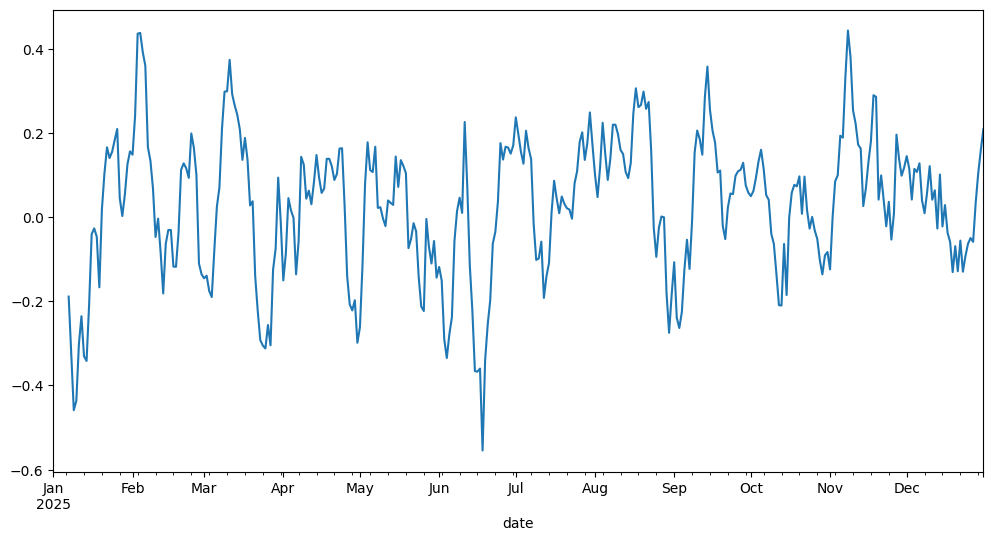

In [2]:
#Data preparation

sentiments = pd.read_csv("..\\..\\data\\news_processed\\aggregated_daily_finbert.csv", index_col=0, parse_dates=True)
sentiments['diff_ma7'].plot(figsize=(12, 6))

sent = sentiments['diff_ma7'].dropna()
sentiment_FR = sentiments['sent_fr_ma7'].dropna()
sentiment_DE = sentiments['sent_de_ma7'].dropna()

<Axes: xlabel='observation_date'>

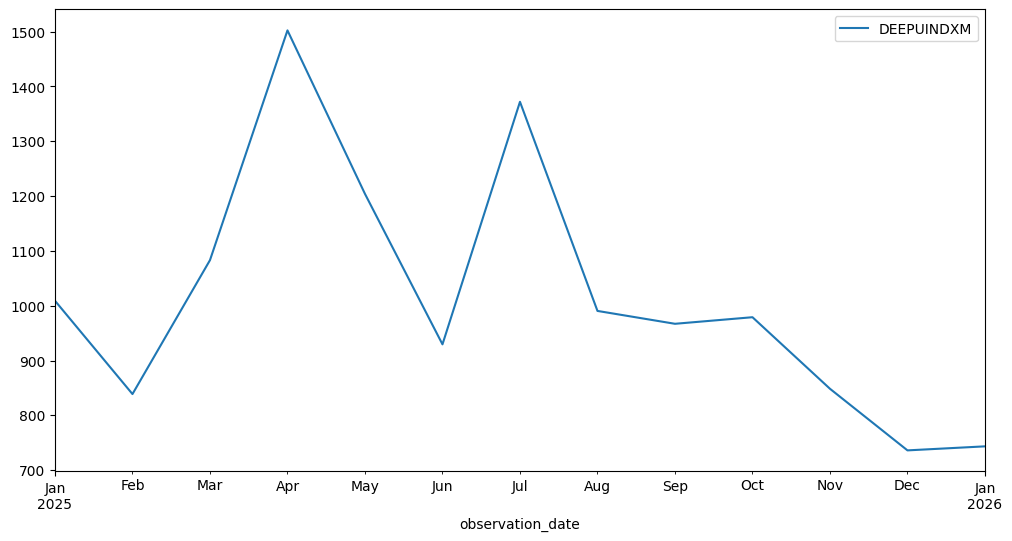

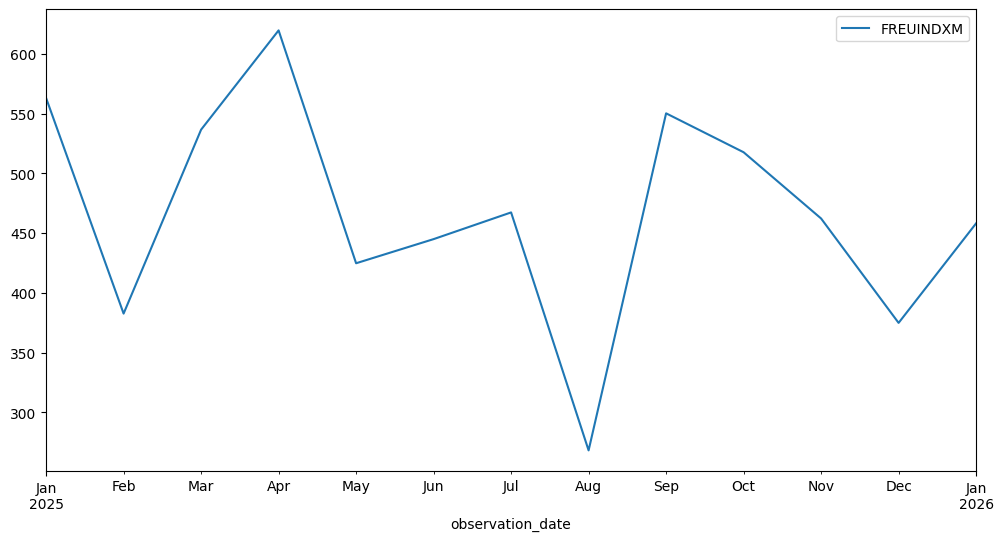

In [3]:
german_uncertainty = pd.read_csv("..\\..\\data\\other_indices\\DEEPUINDXM.csv", index_col=0, parse_dates=True)
german_uncertainty = german_uncertainty[german_uncertainty.index >= start_date]
german_uncertainty.plot(figsize=(12, 6))

french_uncertainty = pd.read_csv("..\\..\\data\\other_indices\\FREUINDXM.csv", index_col=0, parse_dates=True)
french_uncertainty = french_uncertainty[french_uncertainty.index >= start_date]
french_uncertainty.plot(figsize=(12, 6))

On veut maintenant certaines variables macro : PIB, Inflation, Dette, Spread OAT/Bund, Volatilité CAC40, Ecart des taux cours et long

In [4]:
#UNETOT_FR : Total unemployment in France
#UNEO25_FR : Unemployment : Over 25 years in France
#UNEU25_FR : Unemployment : Under 25 years in France
#REER42_FR : Real Exchange Rate (42 main industrial countries)
#LTIRT_FR : Long-term interest rate in France (EMU Criterion)
#IPMN_FR : Industrial production index Manufacturing in France
#IPCAG_FR : Industrial Production Index: Capital Goods in France
#IPCOG_FR' : Industrial Production Index: Consumer Goods in France
#'IPDCOG_FR' : Industrial Production Index: Durable Consumer Goods, 
# 'IPNDCOG_FR' :  Industrial Production Index: Non Durable Consumer Goods,
#'IPING_FR' : Industrial Production Index: Intermediate Goods
#'IPNRG_FR' :  Industrial Production Index: Energy, 
#'TRNMN_FR' : Turnover Index: Manufacturing
#'TRNCAG_FR' : Turnover Index: Capital Goods, 
#'TRNCOG_FR' : Turnover Index: Consumer Goods,
#'TRNDCOG_FR' : Turnover Index: Durable Consumer Goods,
#'TRNNDCOG_FR' : Turnover Index: Non Durable Consumer Goods,
#'TRNING_FR' : Turnover Index: Intermediate Goods,
#'TRNNRG_FR' : Turnover Index: Energy,
#'PPICAG_FR' : Producer Price Index: Capital Goods,
#'PPICOG_FR' : Producer Price Index: Consumer Goods,
#'PPINDCOG_FR': Producer Price Index: Non Durable Consumer Goods
#'PPIDCOG_FR' : Producer Price Index: Durable Consumer Goods,
#'PPIING_FR' : Producer Price Index: Intermediate Goods,
#'PPINRG_FR' : Producer Price Index: Energy,
# 'HICPOV_FR' :  Harmonized Index of Consumer Prices: Overall Index 
# 'HICPNEF_FR' : Harmonized Index of Consumer Prices: All Items: no Energy & Food
# 'HICPG_FR' : Harmonized Index of Consumer Prices: Goods
# 'HICPIN_FR' : Harmonized Index of Consumer Prices: Industrial Goods
# 'HICPSV_FR' : Harmonized Index of Consumer Prices: Services
# 'HICPNG_FR' : Harmonized Index of Consumer Prices: Non-Industrial Goods
# 'SHIX_FR' : Share price index: CAC 40 in France

In [5]:
# 1) Dates trimestrielles (fin de trimestre)
dates_q = pd.date_range("2025-03-31", "2025-12-31", freq="Q")

french_PIB = [0.001, 0.003, 0.005, 0.002]  # variation trimestrielle
german_PIB = [0.004, -0.002, 0.000, 0.003] # variation trimestrielle

gdp_fr_q = pd.DataFrame({"gdp_fr_q": french_PIB}, index=dates_q)
gdp_de_q = pd.DataFrame({"gdp_de_q": german_PIB}, index=dates_q)

def upsample_to_daily_q(df, dates_daily):
    """
    df: DataFrame trimestriel (index Datetime)
    dates_daily: index journalier
    -> rend journalier par interpolation dans le temps.
    """
    df = df.asfreq("Q").sort_index()
    daily = (
        df
        .reindex(dates_daily)
        .interpolate(method="time")
        .dropna()
    )
    return daily

gdp_fr_d = upsample_to_daily_q(gdp_fr_q, dates_daily)  # Series journalière
gdp_de_d = upsample_to_daily_q(gdp_de_q, dates_daily)  # Series journalière

C:\Users\elyan\AppData\Local\Temp\ipykernel_18388\1511790885.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  dates_q = pd.date_range("2025-03-31", "2025-12-31", freq="Q")
C:\Users\elyan\AppData\Local\Temp\ipykernel_18388\1511790885.py:16: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df = df.asfreq("Q").sort_index()
C:\Users\elyan\AppData\Local\Temp\ipykernel_18388\1511790885.py:16: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df = df.asfreq("Q").sort_index()


In [6]:
french_debt = [114, 115.7, 117.4, 119.2]   # 1er–4e trimestre 2025
german_debt = [62.0, 62.3, 63.0, 63.2]   # 1er–4e trimestre 2025

debt_fr_q = pd.DataFrame({"debt_fr": french_debt}, index=dates_q)
debt_de_q = pd.DataFrame({"debt_de": german_debt}, index=dates_q)

debt_fr_d = upsample_to_daily_q(debt_fr_q, dates_daily)  # journalier
debt_de_d = upsample_to_daily_q(debt_de_q, dates_daily)  # journalier

C:\Users\elyan\AppData\Local\Temp\ipykernel_18388\1511790885.py:16: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df = df.asfreq("Q").sort_index()
C:\Users\elyan\AppData\Local\Temp\ipykernel_18388\1511790885.py:16: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df = df.asfreq("Q").sort_index()


In [7]:
french_short_rate = pd.read_csv("..\\..\\data\\short_rate\\FR_short.csv", index_col=0,dayfirst=True, parse_dates=True)
french_short_rate.index = pd.to_datetime(french_short_rate.index, dayfirst=True)
french_short_rate = french_short_rate['Dernier']
french_short_rate = french_short_rate.sort_index(ascending=True)
french_short_rate.replace(",", ".", inplace=True)
french_short_rate = pd.to_numeric(
    french_short_rate.astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)

french_long_rate = pd.read_csv("..\\..\\data\\raw\\Rendement de l'Obligation France 10 ans - Données Historiques (1).csv", index_col=0)
french_long_rate = french_long_rate['Dernier']
french_long_rate.index = pd.to_datetime(french_long_rate.index, dayfirst=True)
french_long_rate = french_long_rate.sort_index(ascending=True)
french_long_rate = french_long_rate[french_long_rate.index >= start_date]
french_long_rate = pd.to_numeric(
    french_long_rate.astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)
german_short_rate = pd.read_csv("..\\..\\data\\short_rate\\DE_short.csv", index_col=0)
german_short_rate.index = pd.to_datetime(german_short_rate.index, dayfirst=True)
german_short_rate = german_short_rate['Dernier'] #Daily
german_short_rate = german_short_rate.sort_index(ascending=True)
german_short_rate =pd.to_numeric(
    german_short_rate.astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)


german_long_rate = pd.read_csv("..\\..\\data\\raw\\Rendement de l'Obligation Allemagne 10 ans - Données Historiques.csv", index_col=0)
german_long_rate = german_long_rate['Dernier']
german_long_rate.index = pd.to_datetime(german_long_rate.index, dayfirst=True)
german_long_rate = german_long_rate.sort_index(ascending=True)
german_long_rate = german_long_rate[german_long_rate.index >= start_date]
german_long_rate = pd.to_numeric(
    german_long_rate.astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)



<Axes: xlabel='Date'>

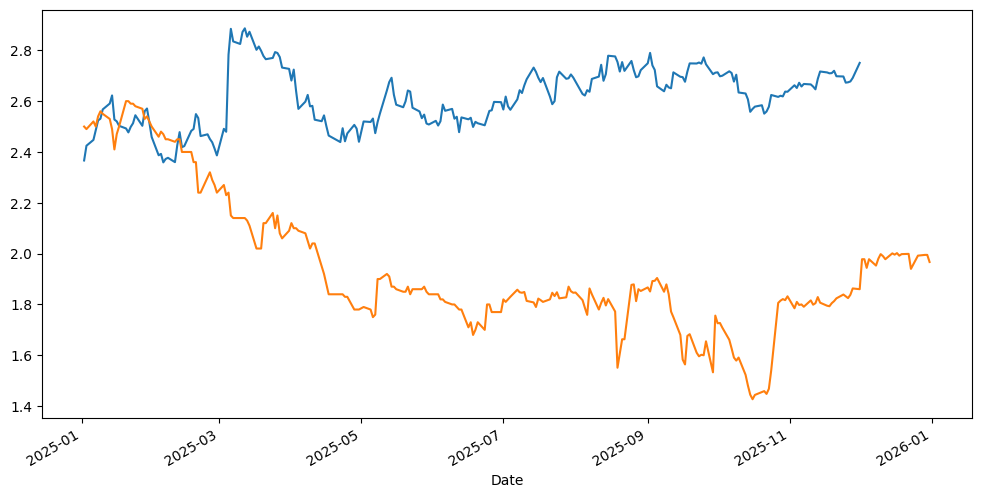

In [8]:
german_long_rate.plot(figsize=(12, 6))
german_short_rate.plot(figsize=(12, 6))

In [9]:
sentiment_FR = sentiment_FR.reindex(dates_daily, method="nearest").interpolate(method="time")
sentiment_DE = sentiment_DE.reindex(dates_daily, method='nearest').interpolate(method  = "time" ) 

In [ ]:
df_var = pd.DataFrame(index=dates_daily)

# Macro trimestrielles rendues journalières
df_var["gdp_fr"]     = gdp_fr_d
df_var["gdp_de"]     = gdp_de_d
df_var["debt_fr"]    = debt_fr_d
df_var["debt_de"]    = debt_de_d

# Taux
df_var["sr_fr"]      = french_short_rate.astype(float)
df_var["sr_de"]      = german_short_rate.astype(float)
df_var["lr_fr"]      = french_long_rate.astype(float)
df_var["lr_de"]      = german_long_rate.astype(float)

# Sentiment (à remplacer par tes vraies séries journalières)
df_var["sentiment_FR"] = sentiment_FR
df_var["sentiment_DE"] = sentiment_DE

# Spread OAT/Bund (si tu veux l’ajouter directement)
#df_var["spread_OAT_Bund"] = df_var["lr_fr"] - df_var["lr_de"]  # ou ton calcul spécifique

# Nettoyage final
df_var = df_var.dropna()
print(df_var.tail())

              gdp_fr    gdp_de     debt_fr    debt_de  sr_fr  sr_de  lr_fr  \
2025-11-25  0.003174  0.001826  118.495652  63.121739  2.048  1.832  3.411   
2025-11-26  0.003141  0.001859  118.515217  63.123913  2.054  1.825  3.395   
2025-11-27  0.003109  0.001891  118.534783  63.126087  2.054  1.838  3.409   
2025-11-28  0.003076  0.001924  118.554348  63.128261  2.046  1.863  3.413   
2025-12-01  0.002978  0.002022  118.613043  63.134783  2.093  1.860  3.485   

             lr_de  sentiment_FR  sentiment_DE  
2025-11-25  2.6728     -0.158107     -0.104674  
2025-11-26  2.6741     -0.117755     -0.125767  
2025-11-27  2.6775     -0.046874     -0.242883  
2025-11-28  2.6913     -0.004062     -0.142840  
2025-12-01  2.7505      0.060560     -0.084314  


c:\Users\elyan\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 21, Apr, 2026
Time:                     15:04:52
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                   -66.2599
Nobs:                     170.000    HQIC:                  -67.1149
Log likelihood:           4385.07    FPE:                3.97740e-30
AIC:                     -67.6987    Det(Omega_mle):     2.55615e-30
--------------------------------------------------------------------
Results for equation OAT_Bund
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const              -0.131780         0.097815           -1.347           0.178
L1.OAT_Bund         0.729633         0.080645            9.047           0.000
L1.s_FR-DE         -0.006114         0.014404           -0.424   

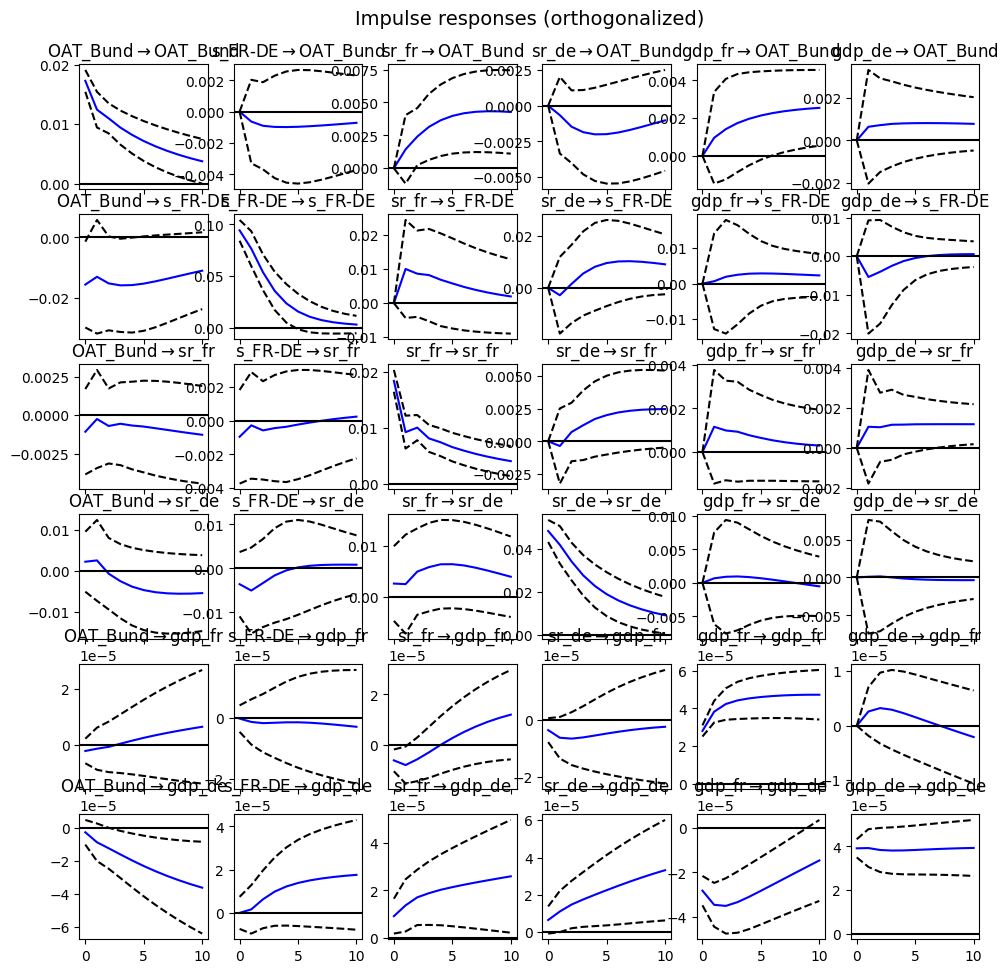

In [17]:
# Nouvelle DataFrame allégée
df_small = pd.DataFrame({
    "OAT_Bund": df_var["lr_fr"] - df_var["lr_de"],  # ou directement ta cible
    "s_FR-DE":    df_var["sentiment_FR"] - df_var["sentiment_DE"],
    "sr_fr":           df_var["sr_fr"],
    "sr_de":           df_var["sr_de"],
    "gdp_fr":          df_var["gdp_fr"],  # ou seulement un indicateur de “croissance France”
    "gdp_de":          df_var["gdp_de"]
}, index=df_var.index)

var_model = model_VAR(max_lag=4, data=df_small)
results = var_model.fit()
print(results.summary())
var_model.irf(steps=10)